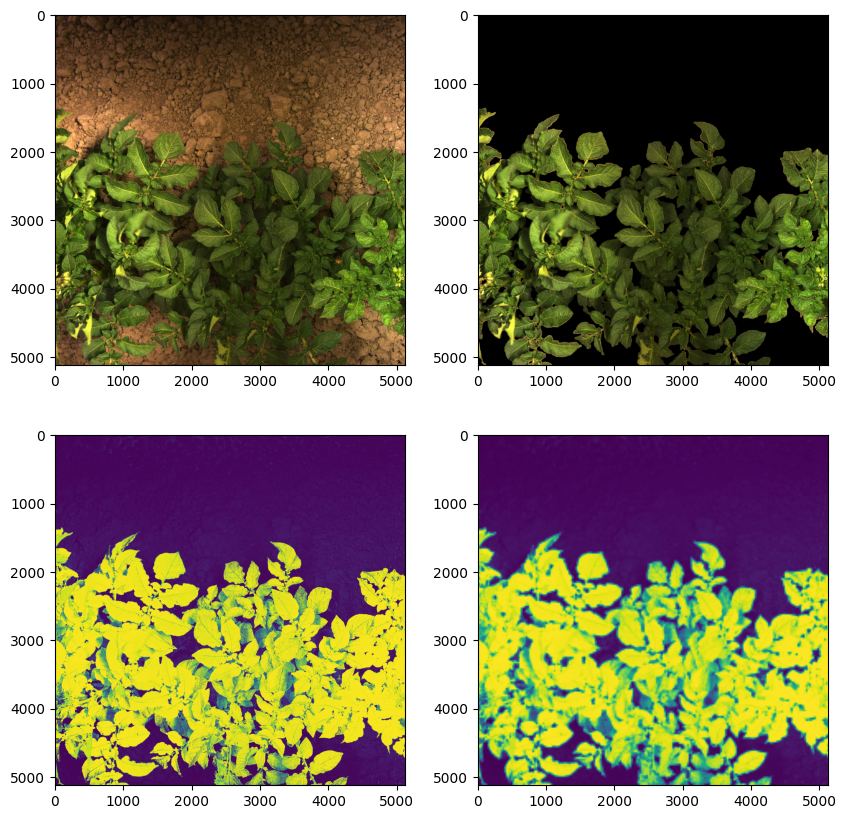

In [6]:
# Parameters

ds = 24           # downscale factor for probability smoothing
p_threshold = 0.3 # (average) probability threshold

import torch
import alvq
import cv2
import numpy as np
import matplotlib.pyplot as plt

net = torch.load('pix-classifier-alvq-2025-07-09.pt', weights_only=False)

img = cv2.imread('../../Croptimal/2024_5_13_CleansingDataset/Run1_light_normal_otherobjects/train/2ec83b5a-f1ad-4dae-bb33-773f1eee7923.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

rgb_feats = (img[..., 0:3].astype(np.float32) * (1/255)).reshape(-1, 3)

with torch.no_grad():
    scalar = net.probabilities(torch.from_numpy(rgb_feats))

width = img.shape[1]
height = img.shape[0]

scalar = scalar[..., 1].reshape(img.shape[0:2])
scalar_orig = scalar
scalar = cv2.resize(scalar.numpy(), (width // ds, height // ds), interpolation=cv2.INTER_AREA)
scalar = cv2.resize(scalar, (width, height), interpolation=cv2.INTER_LINEAR)

fig, axes = plt.subplots(2, 2, figsize=(10,10))
axes[0][0].imshow(img)
img2 = img.copy()
img2[scalar < p_threshold, :] = 0
axes[0][1].imshow(img2)
axes[1][0].imshow(scalar_orig)
axes[1][1].imshow(scalar)